# Day 6 – Classification Fundamentals
### 20-Day ML Revision Planner | Phase: Core ML

**Topics covered:**
1. Logistic Regression
2. The Sigmoid Function
3. Odds and Log-Odds
4. Decision Boundary
5. Log Loss / Cross-Entropy
6. K-Nearest Neighbors (KNN)
7. Naive Bayes (recap + classification framing)
8. Coding: Train All Three on the Same Dataset (Breast Cancer)
9. Classification Comparison Table
10. Interview Questions
11. Active Recall Checklist

**Revision rule:** Learn → Close Notes → Recall → Code → Debug → Explain → Interview Question.

---


In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay)

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 4)
np.random.seed(42)
print("Setup complete.")


Setup complete.


## 1. Logistic Regression

### What?
Despite the name, **Logistic Regression is a classification algorithm**. It models the **probability** that an input belongs to a class, using a linear combination of features passed through a **sigmoid** function.

$$P(y=1 \mid x) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

### Why?
It's the natural extension of linear regression to classification: instead of predicting an unbounded continuous value, we squash the linear output into a valid probability in $[0, 1]$.

### How?
1. Compute the linear combination $z = \mathbf{w}^T\mathbf{x} + b$ (exactly like linear regression).
2. Pass $z$ through the sigmoid function to get a probability.
3. Apply a threshold (commonly 0.5) to convert the probability into a class prediction.


## 2. The Sigmoid Function

### What?
$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Maps any real number $z \in (-\infty, \infty)$ to a value in $(0, 1)$ — perfect for representing a probability.

### Why?
- $\sigma(z) \to 1$ as $z \to +\infty$
- $\sigma(z) \to 0$ as $z \to -\infty$
- $\sigma(0) = 0.5$ — the natural decision threshold

### How?
Its S-shape means it's very sensitive near $z=0$ (small changes flip the decision) and flat/saturated for large $|z|$ (confident predictions).


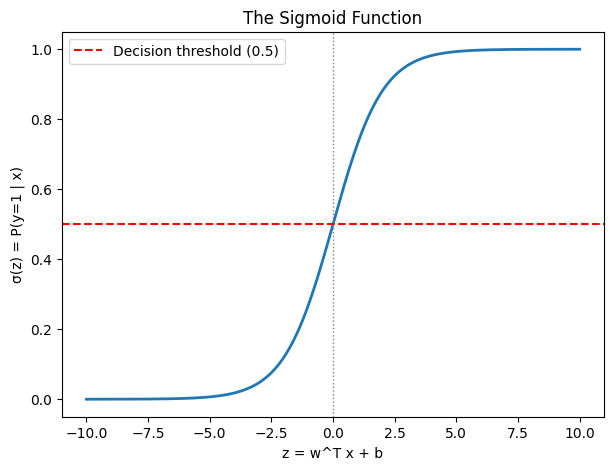

σ(0)   = 0.5  (exactly the decision boundary)
σ(5)   = 0.9933  (confidently class 1)
σ(-5)  = 0.0067  (confidently class 0)


In [2]:
# Visualize the sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_vals = np.linspace(-10, 10, 200)
sigmoid_vals = sigmoid(z_vals)

plt.figure(figsize=(7, 5))
plt.plot(z_vals, sigmoid_vals, linewidth=2)
plt.axhline(0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
plt.axvline(0, color='gray', linestyle=':', linewidth=1)
plt.xlabel("z = w^T x + b"); plt.ylabel("σ(z) = P(y=1 | x)")
plt.title("The Sigmoid Function")
plt.legend()
plt.show()

print("σ(0)   =", sigmoid(0), " (exactly the decision boundary)")
print("σ(5)   =", round(sigmoid(5), 4), " (confidently class 1)")
print("σ(-5)  =", round(sigmoid(-5), 4), " (confidently class 0)")


## 3. Odds and Log-Odds

### What?
- **Odds**: the ratio of probability of an event happening to it not happening.
  $$\text{Odds} = \frac{P(y=1)}{1 - P(y=1)}$$
- **Log-odds (logit)**: the natural log of the odds — and it turns out logistic regression is *linear* in the log-odds!
  $$\ln\left(\frac{P(y=1)}{1-P(y=1)}\right) = \mathbf{w}^T\mathbf{x} + b$$

### Why?
This is *why* logistic regression coefficients are interpretable: each weight $w_i$ represents the change in **log-odds** for a one-unit increase in feature $x_i$ (holding others constant). Exponentiating a coefficient, $e^{w_i}$, gives the **odds ratio** — a common way to interpret logistic regression in fields like medicine and finance.

### How?
The sigmoid function is exactly the **inverse** of the logit function — that's the elegant mathematical link connecting linear regression's output to a probability.


In [3]:
# Demonstrate the odds / log-odds relationship
probabilities = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
odds = probabilities / (1 - probabilities)
log_odds = np.log(odds)

odds_table = pd.DataFrame({
    'Probability': probabilities,
    'Odds': odds,
    'Log-Odds (logit)': log_odds
})
print(odds_table)

print("\nVerify sigmoid(logit(p)) recovers p:")
recovered_p = sigmoid(log_odds)
print("Recovered probabilities:", np.round(recovered_p, 4))
print("--> sigmoid() and the logit/log-odds function are perfect inverses of each other.")


   Probability    Odds  Log-Odds (logit)
0          0.1  0.1111           -2.1972
1          0.3  0.4286           -0.8473
2          0.5  1.0000            0.0000
3          0.7  2.3333            0.8473
4          0.9  9.0000            2.1972

Verify sigmoid(logit(p)) recovers p:
Recovered probabilities: [0.1 0.3 0.5 0.7 0.9]
--> sigmoid() and the logit/log-odds function are perfect inverses of each other.


## 4. Decision Boundary

### What?
The **decision boundary** is the surface in feature space where the model is indifferent between classes — i.e., where $P(y=1|x) = 0.5$, equivalently where $z = \mathbf{w}^T\mathbf{x} + b = 0$.

### Why?
For logistic regression, this boundary is always **linear** (a straight line in 2D, a plane/hyperplane in higher dimensions) — this is an important limitation to know: logistic regression cannot capture non-linear class boundaries without feature engineering (e.g., polynomial features) or a different algorithm.

### How?
Everything on one side of the boundary ($z > 0$) is classified as class 1; everything on the other side ($z < 0$) is classified as class 0.


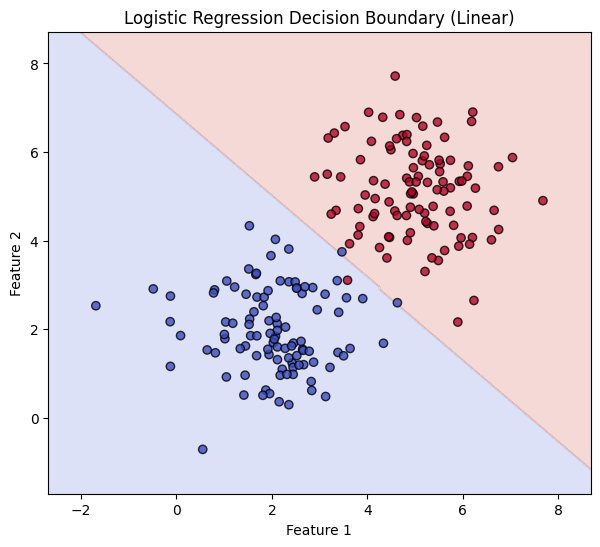

In [4]:
# Visualize a linear decision boundary on a 2D toy classification problem
np.random.seed(6)
class0 = np.random.normal([2, 2], 1.0, (100, 2))
class1 = np.random.normal([5, 5], 1.0, (100, 2))
X_2d = np.vstack([class0, class1])
y_2d = np.array([0]*100 + [1]*100)

log_reg_2d = LogisticRegression().fit(X_2d, y_2d)

xx, yy = np.meshgrid(np.linspace(X_2d[:,0].min()-1, X_2d[:,0].max()+1, 200),
                      np.linspace(X_2d[:,1].min()-1, X_2d[:,1].max()+1, 200))
Z = log_reg_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='coolwarm', edgecolor='k', alpha=0.8)
plt.title("Logistic Regression Decision Boundary (Linear)")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.show()


## 5. Log Loss / Cross-Entropy

### What?
The cost function for logistic regression — **NOT** MSE (which would produce a non-convex loss surface for a sigmoid model). Instead, we use **Log Loss / Binary Cross-Entropy**:

$$J(\mathbf{w}) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]$$

### Why?
- This loss is **convex** for logistic regression, so gradient descent reliably finds the global minimum.
- It **heavily penalizes confident-but-wrong predictions**: if the true label is 1 but the model predicts $\hat{y} \approx 0$, $-\log(\hat{y})$ blows up toward infinity.

### How?
- If $y=1$: loss $= -\log(\hat{y})$ → small when $\hat{y}$ is close to 1, huge when close to 0.
- If $y=0$: loss $= -\log(1-\hat{y})$ → small when $\hat{y}$ is close to 0, huge when close to 1.


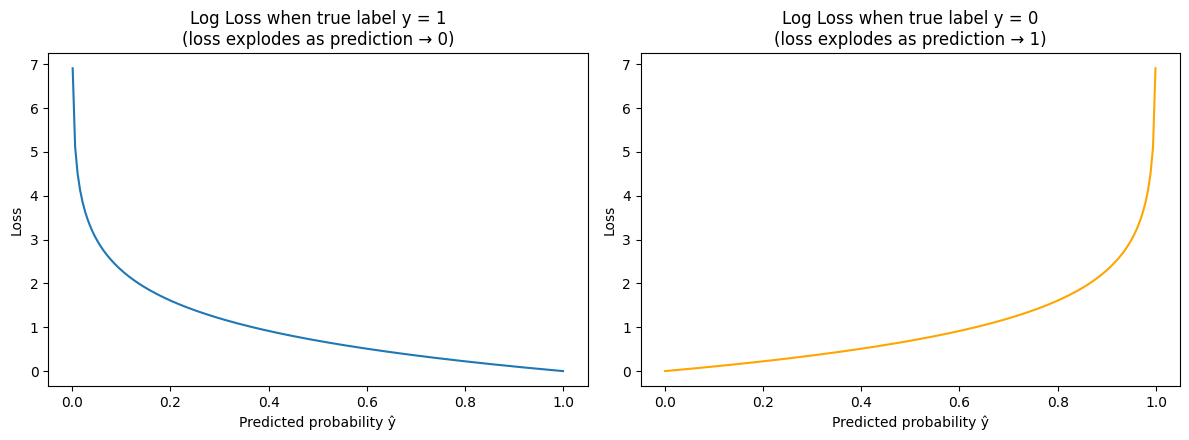

Loss if y=1 and model predicts 0.9 (good, confident & correct): 0.1054
Loss if y=1 and model predicts 0.1 (bad, confident & WRONG):    2.3026


In [5]:
# Visualize log loss for the y=1 and y=0 cases
p_hat = np.linspace(0.001, 0.999, 200)
loss_if_y1 = -np.log(p_hat)
loss_if_y0 = -np.log(1 - p_hat)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(p_hat, loss_if_y1)
axes[0].set_title("Log Loss when true label y = 1\n(loss explodes as prediction → 0)")
axes[0].set_xlabel("Predicted probability ŷ"); axes[0].set_ylabel("Loss")

axes[1].plot(p_hat, loss_if_y0, color='orange')
axes[1].set_title("Log Loss when true label y = 0\n(loss explodes as prediction → 1)")
axes[1].set_xlabel("Predicted probability ŷ"); axes[1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

# Concrete example: confidently wrong prediction is penalized heavily
print("Loss if y=1 and model predicts 0.9 (good, confident & correct):", round(-np.log(0.9), 4))
print("Loss if y=1 and model predicts 0.1 (bad, confident & WRONG):   ", round(-np.log(0.1), 4))


## 6. K-Nearest Neighbors (KNN)

### What?
A **non-parametric, instance-based** algorithm: to classify a new point, find its $K$ closest neighbors (by some distance metric, e.g. Euclidean — recall Day 1's L2 norm) in the training data, and assign the **majority class** among them.

### Why?
KNN makes **no assumptions** about the underlying data distribution or decision boundary shape — it can capture highly non-linear boundaries naturally, unlike logistic regression.

### How?
1. Choose $K$ (number of neighbors) and a distance metric.
2. For a new point, compute distances to all training points.
3. Select the $K$ nearest, take a majority vote (classification) or average (regression).

### Key considerations
- **Small $K$** → low bias, high variance (sensitive to noise, can overfit).
- **Large $K$** → high bias, low variance (smoother boundary, can underfit; and if $K$ = total samples, always predicts the majority class).
- **Feature scaling is critical** (recall Day 4) — KNN relies entirely on distance, so unscaled features with larger ranges dominate.
- Computationally expensive at prediction time (must compare to all training points) — "lazy learning."


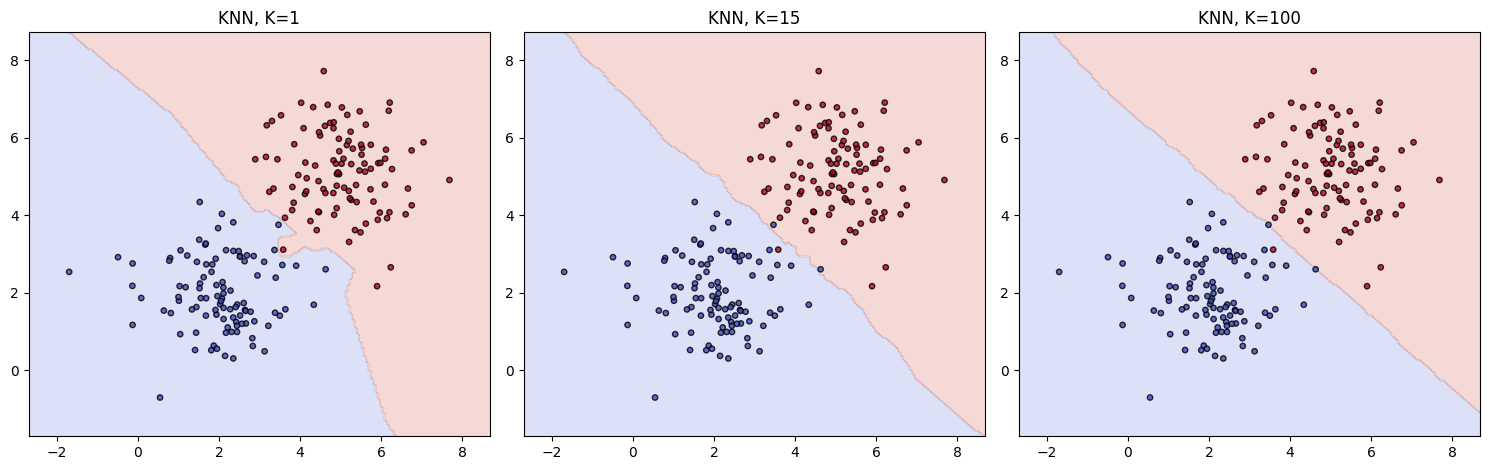

--> K=1: jagged, overfit boundary (memorizes noise). K=100 (~half the data): oversmoothed, underfit.


In [6]:
# Visualize how K affects the KNN decision boundary (bias-variance trade-off in action)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

for ax, k in zip(axes, [1, 15, 100]):
    knn_demo = KNeighborsClassifier(n_neighbors=k).fit(X_2d, y_2d)
    Z_knn = knn_demo.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z_knn, alpha=0.2, cmap='coolwarm')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap='coolwarm', edgecolor='k', alpha=0.8, s=15)
    ax.set_title(f"KNN, K={k}")

plt.tight_layout()
plt.show()
print("--> K=1: jagged, overfit boundary (memorizes noise). K=100 (~half the data): oversmoothed, underfit.")


## 7. Naive Bayes (Recap — Classification Framing)

### What?
From Day 3: Naive Bayes uses **Bayes' theorem** with a "naive" **conditional independence** assumption between features to compute:

$$P(\text{class} \mid \text{features}) \propto P(\text{class}) \prod_i P(\text{feature}_i \mid \text{class})$$

For continuous features, **Gaussian Naive Bayes** assumes each feature is normally distributed within each class.

### Why (in a classification context)?
- Extremely fast to train (just estimate means/variances/priors — no iterative optimization).
- Works surprisingly well even when the independence assumption is violated.
- A strong, cheap **baseline** to compare more complex models against.

### How?
Compute the posterior probability for each class using the training-set-derived priors and per-feature likelihoods, then pick the class with the highest posterior (exactly what we implemented from scratch on Day 3).


## 8. Coding Practice — Train Logistic Regression, KNN, and Naive Bayes on the Same Dataset

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — a classic binary classification dataset (malignant vs. benign tumors) bundled with scikit-learn.


In [7]:
# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = malignant, 1 = benign

print("Dataset shape:", X.shape)
print("Class distribution:\n", y.value_counts())
print("\nClass names:", dict(enumerate(data.target_names)))
X.head()


Dataset shape: (569, 30)
Class distribution:
 target
1    357
0    212
Name: count, dtype: int64

Class names: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


In [8]:
# Train/test split, then scale (fit on train only!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print("Note: KNN and Logistic Regression both need scaled features; Naive Bayes doesn't strictly")
print("require it, but we use the same scaled data for a fair, consistent comparison.")


Train: 426 samples | Test: 143 samples
Note: KNN and Logistic Regression both need scaled features; Naive Bayes doesn't strictly
require it, but we use the same scaled data for a fair, consistent comparison.


In [9]:
# Train all three models
log_reg = LogisticRegression(max_iter=5000, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)
nb = GaussianNB()

models = {
    'Logistic Regression': log_reg,
    'KNN (k=5)': knn,
    'Naive Bayes': nb
}

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

print("All three models trained successfully.")


All three models trained successfully.


## 9. Classification Comparison Table

We now compare all three models using **Accuracy, Precision, Recall, F1-score, and ROC-AUC** — the primary classification metrics (covered in full depth on Day 10).

Quick definitions:
- **Accuracy**: fraction of correct predictions overall.
- **Precision**: of predicted positives, how many were actually positive? (Cost of false positives.)
- **Recall**: of actual positives, how many did we catch? (Cost of false negatives — critical in medical diagnosis!)
- **F1-score**: harmonic mean of precision and recall, useful when you need a single balanced metric.
- **ROC-AUC**: how well the model ranks positive cases above negative cases across all thresholds.


In [10]:
# Build the comparison table
comparison_results = []
for name in models:
    y_pred = predictions[name]
    y_prob = probabilities[name]
    comparison_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(comparison_results).set_index('Model')
print(comparison_df.round(4))


                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Model                                                              
Logistic Regression    0.9860     0.9889  0.9889    0.9889   0.9977
KNN (k=5)              0.9790     0.9677  1.0000    0.9836   0.9845
Naive Bayes            0.9371     0.9355  0.9667    0.9508   0.9878


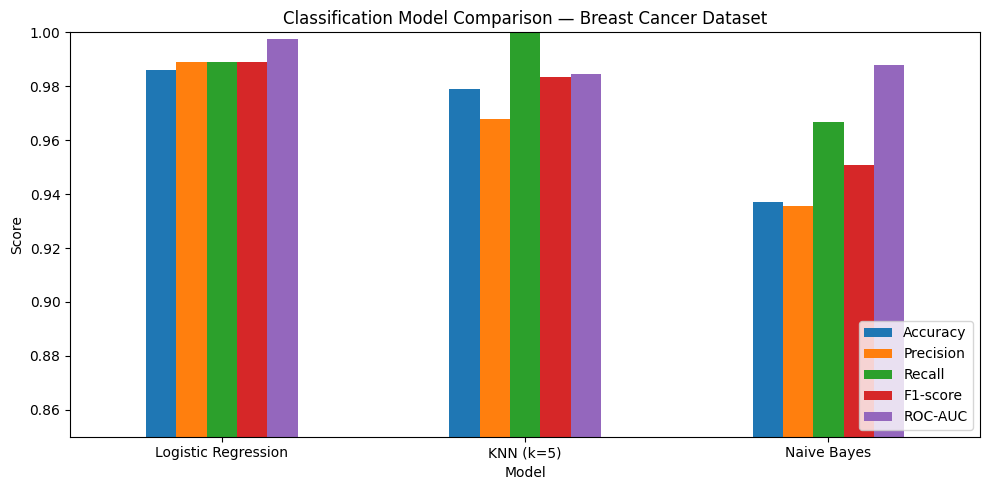

In [11]:
# Visualize the comparison as a grouped bar chart
comparison_df.plot(kind='bar', figsize=(10, 5), ylim=(0.85, 1.0))
plt.title("Classification Model Comparison — Breast Cancer Dataset")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


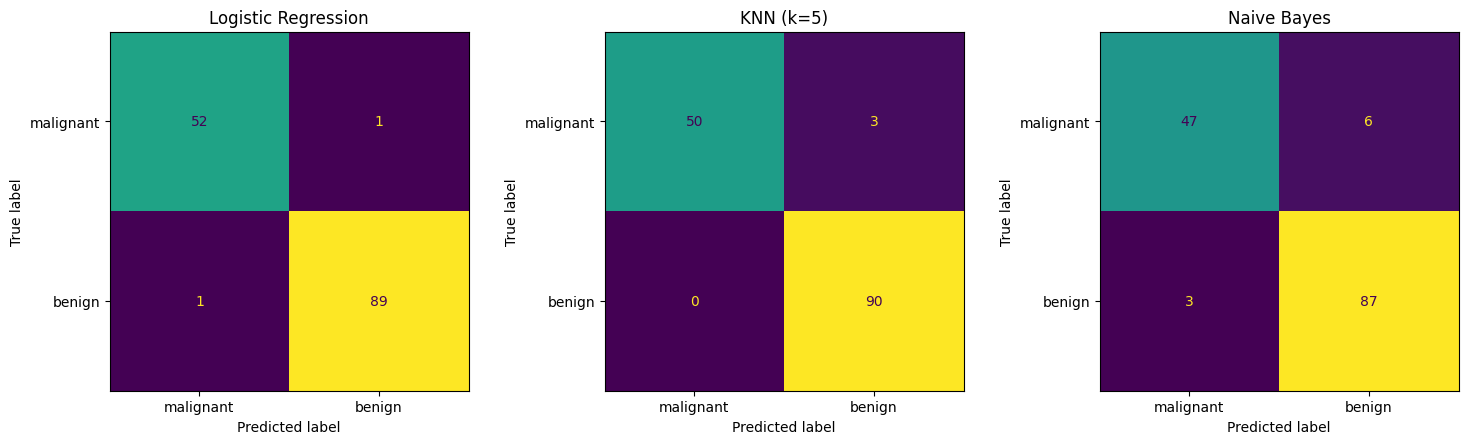

In [12]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


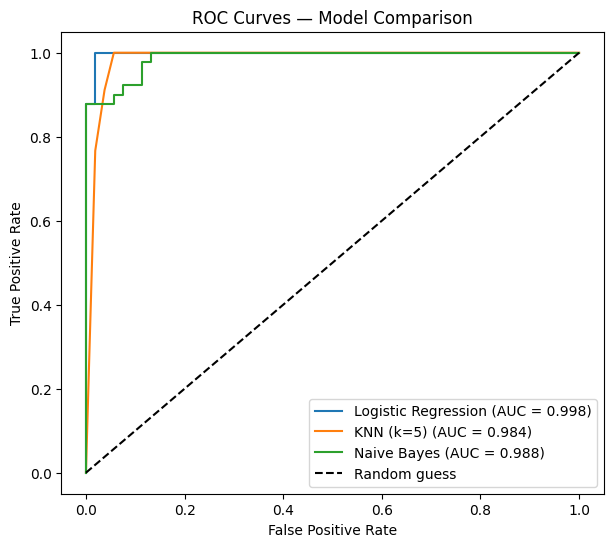

In [13]:
# ROC curves for all three models on one plot
plt.figure(figsize=(7, 6))
for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.show()


In [14]:
# Working notebook output: which model wins on which metric?
print("Best model per metric:")
for metric in comparison_df.columns:
    best_model = comparison_df[metric].idxmax()
    print(f"  {metric}: {best_model} ({comparison_df.loc[best_model, metric]:.4f})")

print("\nInterpretation:")
print("- Logistic Regression and KNN often perform very similarly on this dataset (linearly separable-ish data).")
print("- Naive Bayes can lag slightly since its independence assumption doesn't perfectly hold for correlated")
print("  tumor measurement features (e.g., radius, perimeter, and area are highly correlated).")
print("- In a medical context, Recall is often prioritized over Precision -- missing a malignant tumor")
print("  (false negative) is far more costly than a false alarm (false positive).")


Best model per metric:
  Accuracy: Logistic Regression (0.9860)
  Precision: Logistic Regression (0.9889)
  Recall: KNN (k=5) (1.0000)
  F1-score: Logistic Regression (0.9889)
  ROC-AUC: Logistic Regression (0.9977)

Interpretation:
- Logistic Regression and KNN often perform very similarly on this dataset (linearly separable-ish data).
- Naive Bayes can lag slightly since its independence assumption doesn't perfectly hold for correlated
  tumor measurement features (e.g., radius, perimeter, and area are highly correlated).
- In a medical context, Recall is often prioritized over Precision -- missing a malignant tumor
  (false negative) is far more costly than a false alarm (false positive).


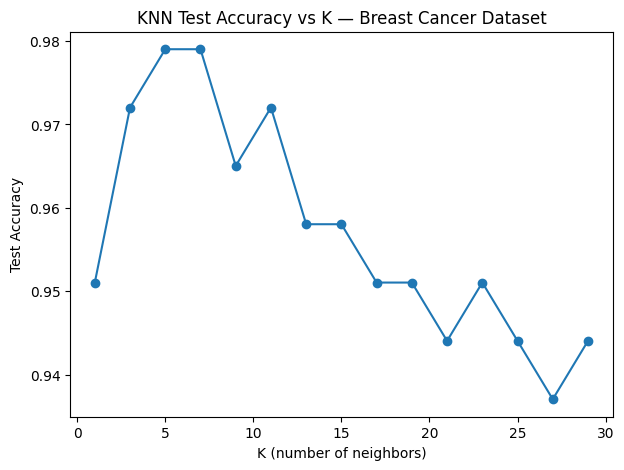

Best K found: 5, with accuracy 0.9790


In [15]:
# Debug/explore exercise: how does K affect KNN performance on this real dataset?
k_values = range(1, 31, 2)
k_accuracies = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    k_accuracies.append(accuracy_score(y_test, knn_k.predict(X_test_scaled)))

plt.figure(figsize=(7, 5))
plt.plot(list(k_values), k_accuracies, marker='o')
plt.xlabel("K (number of neighbors)"); plt.ylabel("Test Accuracy")
plt.title("KNN Test Accuracy vs K — Breast Cancer Dataset")
plt.show()

best_k = list(k_values)[np.argmax(k_accuracies)]
print(f"Best K found: {best_k}, with accuracy {max(k_accuracies):.4f}")


## ML Connection Recap

| Concept | Connects to |
|---|---|
| Sigmoid function | Squashes linear output (Day 1/5's $\mathbf{w}^Tx+b$) into a probability |
| Log loss | Convex cost function, optimized via gradient descent (Day 2) |
| KNN distance | Euclidean distance / L2 norm (Day 1), requires scaling (Day 4) |
| Naive Bayes | Bayes' theorem, conditional independence (Day 3) |
| Model comparison | Precision/Recall/F1/ROC-AUC — full depth on Day 10 |


## 10. Interview Questions — Practice Aloud (Close Your Notes!)

1. **Why is logistic regression called "regression" if it's used for classification?**
   *Hint: it regresses (models) the log-odds/probability linearly; the "regression" refers to the underlying linear model, not the output type.*

2. **Why don't we use MSE as the cost function for logistic regression?**
   *Hint: MSE + sigmoid produces a non-convex loss surface with local minima; log loss is convex.*

3. **How does the choice of K affect KNN's bias and variance?**
   *Hint: small K → low bias/high variance (overfitting); large K → high bias/low variance (underfitting).*

4. **Why is feature scaling especially important for KNN but not for Naive Bayes or trees?**
   *Hint: KNN is purely distance-based, so unscaled large-range features dominate; Naive Bayes models each feature's distribution independently, and trees split on order/thresholds per feature.*

5. **What's the relationship between odds, log-odds, and the sigmoid function?**
   *Hint: sigmoid is the inverse of the logit (log-odds) function — logistic regression is linear in log-odds space.*

6. **(Bonus) Why might Naive Bayes underperform when features are highly correlated?**
   *Hint: the independence assumption is violated — correlated evidence gets "double-counted" in the product of likelihoods.*

7. **(Bonus) In a medical diagnosis context, would you optimize for precision or recall? Why?**
   *Hint: usually recall — missing a true positive (a sick patient) is typically far more costly than a false alarm.*


## 11. Active Recall & Daily Output

**Self-check (mark ✔ only if you can do this without notes):**
- [ ] Write the sigmoid function from memory and explain what it does.
- [ ] Explain odds vs log-odds and how they connect logistic regression to a linear model.
- [ ] Explain why logistic regression's decision boundary is always linear.
- [ ] Write the log loss / cross-entropy formula and explain why it's used instead of MSE.
- [ ] Explain how KNN classifies a new point, and the effect of K on bias/variance.
- [ ] Explain why feature scaling matters for KNN specifically.
- [ ] Recall how Naive Bayes computes a classification decision using Bayes' theorem.
- [ ] Train and compare Logistic Regression, KNN, and Naive Bayes on a dataset from memory.

### 📌 Daily Output (per the planner)
A **classification comparison table** (Section 9) evaluating Logistic Regression, KNN, and Naive Bayes on the Breast Cancer dataset across Accuracy, Precision, Recall, F1-score, and ROC-AUC — plus confusion matrices, ROC curves, and a K-sensitivity analysis for KNN, all in this working notebook.

Close this notebook and re-explain, out loud, why each model made the predictions it did on a few individual test samples — that's the real test of Day 6 mastery.
